<a href="https://colab.research.google.com/github/AngieIdrobo/InteligenciaArtificial/blob/main/ASupervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
#Se importan las librerías de machine learning instaladas en colab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             accuracy_score, classification_report,
                             confusion_matrix, r2_score)

In [16]:
# Se genera el dataset
# metodo para que el dataset se pueda reproducir, relacionamos las mismas estaciones y líneas establecidas en el proyecto
# y algunas variables que tendrán datos de entrada

np.random.seed(42)
N = 1000
estaciones = ["UniValle","San Bosco","Estadio","Capri","Universidades","Granada","Salomia","Calima","Menga","Terminal","Centenario"]
lineas = ["T30A","T31A","A33","P1"]

# Los días de la semana se cuentan 0 = Lunes y 1 = martes ...

hora          = np.random.randint(5, 23, N)
dia_semana    = np.random.randint(0, 7, N)
num_paradas   = np.random.randint(1, 10, N)
transbordos   = np.random.randint(0, 3, N)
estacion_orig = np.random.choice(estaciones, N)
estacion_dest = np.random.choice(estaciones, N)
linea         = np.random.choice(lineas, N)

# Problema planteado: ¿Cuánto tardan los viajes en minutos?, se crea la variable
# teniendo en cuenta que las horas pico y los transbordos aumentan el tiempo

tiempo_base = num_paradas * 4.2
factor_hora = np.where ((hora >=7) & (hora <= 9), 1.3,
              np.where ((hora >=17) & (hora <= 19), 1.25, 1.0))
tiempo_transbordo = transbordos * 5
factor_dia = np.where ((dia_semana >= 5), 0.85, 1.0)

tiempo_viaje = (tiempo_base * factor_hora * factor_dia
              + tiempo_transbordo
              + np.random.normal (0, 2, N))

tiempo_viaje = np.round(np.clip(tiempo_viaje, 3, 90), 1)

# Se construye el DataFrame

df = pd.DataFrame ({
    "hora":           hora,
    "dia_semana":     dia_semana,
    "num_paradas":    num_paradas,
    "transbordos":    transbordos,
    "estacion_orig":  estacion_orig,
    "estacion_dest":  estacion_dest,
    "linea":          linea,
    "tiempo_viaje":   tiempo_viaje,
})

print(f"Dataset creado: {df.shape[0]} filas * {df.shape[1]} columnas")
print("\nPrimeras 5 filas:")
df.head(10)


Dataset creado: 1000 filas * 8 columnas

Primeras 5 filas:


,hora,dia_semana,num_paradas,transbordos,estacion_orig,estacion_dest,linea,tiempo_viaje
0,11,4,3,2,Granada,Granada,T30A,24.2
1,19,0,6,1,Universidades,Terminal,A33,37.9
2,15,6,3,2,Centenario,Terminal,T30A,21.0
3,12,0,8,0,San Bosco,Capri,P1,29.9
4,11,5,2,1,Salomia,Menga,A33,13.5
5,15,5,9,0,Capri,Universidades,T31A,33.1
6,15,2,3,1,UniValle,Calima,P1,18.4
7,8,5,5,2,Capri,Menga,T30A,33.6
8,12,3,8,1,Granada,Terminal,P1,36.8
9,7,1,2,1,Salomia,Universidades,T30A,18.1


In [17]:
# guardar el dataset

df.to_csv("dataset_mio.csv", index=False)
print("Archivo guardado: dataset_mio.csv")
print(f"Registros : {df.shape[0]}")
print(f"Columnas  : {df.shape[1]}")

from google.colab import files
files.download("dataset_mio.csv")

Archivo guardado: dataset_mio.csv
Registros : 1000
Columnas  : 8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hora           1000 non-null   int64  
 1   dia_semana     1000 non-null   int64  
 2   num_paradas    1000 non-null   int64  
 3   transbordos    1000 non-null   int64  
 4   estacion_orig  1000 non-null   object 
 5   estacion_dest  1000 non-null   object 
 6   linea          1000 non-null   object 
 7   tiempo_viaje   1000 non-null   float64
dtypes: float64(1), int64(4), object(3)
memory usage: 62.6+ KB
None

 ESTADÍSTICA DESCRIPTIVA
              hora   dia_semana  num_paradas  transbordos  tiempo_viaje
count  1000.000000  1000.000000  1000.000000  1000.000000    1000.00000
mean     13.127000     2.934000     5.044000     0.982000      27.23010
std       5.318379     2.005409     2.547264     0.833289      12.91385
min       5.000000     0.000000     1.000000     0.00

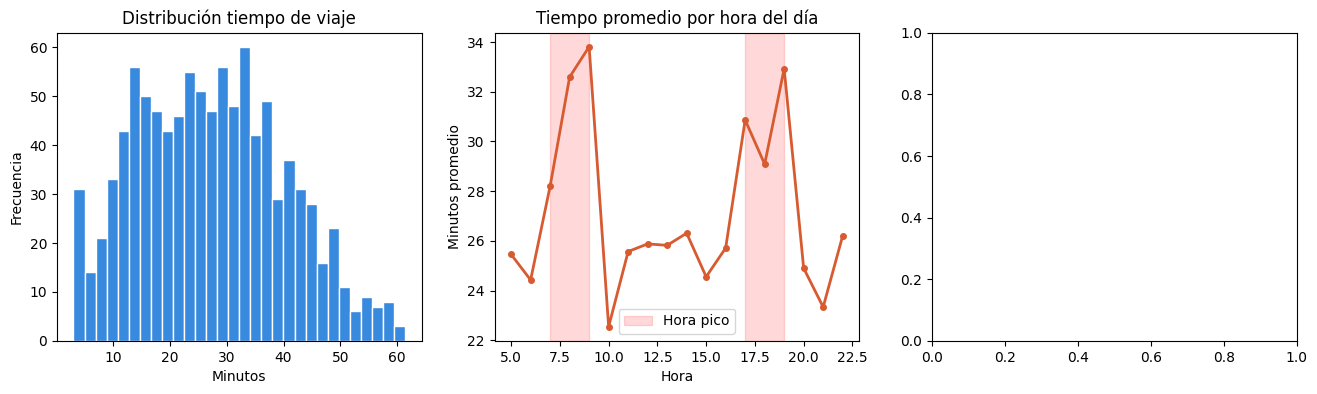

In [18]:
# Se explorará el dataset

print("INFORMACIÓN GENERAL")
print (df.info())

print("\n ESTADÍSTICA DESCRIPTIVA")
print(df.describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución del tiempo de viaje
axes[0].hist(df["tiempo_viaje"], bins=30, color="#378ADD", edgecolor="white")
axes[0].set_title("Distribución tiempo de viaje")
axes[0].set_xlabel("Minutos")
axes[0].set_ylabel("Frecuencia")

# Tiempo promedio por hora

tiempo_por_hora = df.groupby("hora")["tiempo_viaje"].mean()
axes[1].plot(tiempo_por_hora.index, tiempo_por_hora.values,
             color="#D85A30", linewidth=2, marker="o", markersize=4)
axes[1].set_title("Tiempo promedio por hora del día")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Minutos promedio")
axes[1].axvspan(7, 9,   alpha=0.15, color="red", label="Hora pico")
axes[1].axvspan(17, 19, alpha=0.15, color="red")
axes[1].legend()



In [19]:
# Se organizan los datos para ser procesados por ML

le_orig = LabelEncoder()
le_dest = LabelEncoder()
le_linea = LabelEncoder()

df["estacion_orig_enc"] = le_orig.fit_transform(df["estacion_orig"])
df["estacion_dest_enc"] = le_dest.fit_transform(df["estacion_dest"])
df["linea_enc"] = le_linea.fit_transform(df["linea"])

# se relacionan las variables de entradas

FEATURE = ["hora", "dia_semana", "num_paradas", "transbordos",
            "estacion_orig_enc", "estacion_dest_enc","linea_enc"] # Corrected this line

X = df[FEATURE]
y = df["tiempo_viaje"]

# Se escalan los datos para la regresión logistica

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Se divide entre entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento : {X_train.shape[0]} registros")
print(f"Datos de prueba        : {X_test.shape[0]} registros")
print("Features utilizadas ", FEATURE)
print ("Shape de x ", X.shape)

Datos de entrenamiento : 800 registros
Datos de prueba        : 200 registros
Features utilizadas  ['hora', 'dia_semana', 'num_paradas', 'transbordos', 'estacion_orig_enc', 'estacion_dest_enc', 'linea_enc']
Shape de x  (1000, 7)


MODELO 1: REGRESIÓN LINEAL
Objetivo: predecir el tiempo de viaje en minutos

Resultados en datos de prueba:
  MAE  (Error absoluto medio) : 3.26 min
  RMSE (Error cuadrático medio): 4.11 min
  R²   (Bondad de ajuste)     : 0.9133

Coeficientes del modelo (impacto en minutos):
num_paradas          11.217114
transbordos           4.194072
estacion_dest_enc     0.276790
estacion_orig_enc     0.054542
linea_enc            -0.053537
hora                 -0.512874
dia_semana           -1.507906
dtype: float64


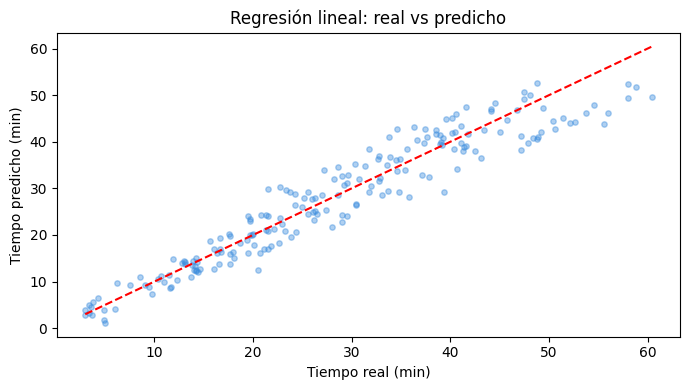

In [20]:
# Modelo para predecir el tiempo del viaje

print("="*50)
print("MODELO 1: REGRESIÓN LINEAL")
print("Objetivo: predecir el tiempo de viaje en minutos")
print("="*50)

y_reg = df["tiempo_viaje"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

y_pred_reg = modelo_regresion.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_reg)
rmse = mean_squared_error(y_test, y_pred_reg) ** 0.5

print(f"\nResultados en datos de prueba:")
print(f"  MAE  (Error absoluto medio) : {mae:.2f} min")
print(f"  RMSE (Error cuadrático medio): {rmse:.2f} min")
print(f"  R²   (Bondad de ajuste)     : {modelo_regresion.score(X_test, y_test):.4f}")

# Importancia de cada variable
coeficientes = pd.Series(modelo_regresion.coef_, index=FEATURE)
print(f"\nCoeficientes del modelo (impacto en minutos):")
print(coeficientes.sort_values(ascending=False))

# Visualizar predicciones vs valores reales
plt.figure(figsize=(7, 4))
plt.scatter(y_test, y_pred_reg, alpha=0.4, color="#378ADD", s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", linewidth=1.5)
plt.xlabel("Tiempo real (min)")
plt.ylabel("Tiempo predicho (min)")
plt.title("Regresión lineal: real vs predicho")
plt.tight_layout()
plt.show()

In [23]:
# pruebas manuales

print("="*50)
print("PRUEBAS MANUALES DEL MODELO")
print("="*50)

casos_prueba = [
    {"descripcion": "Hora pico mañana, ruta larga con transbordo",
     "valores": [8, 1, 8, 2, 0, 5, 0]},
    {"descripcion": "Fin de semana, ruta corta sin transbordo",
     "valores": [11, 6, 3, 0, 1, 3, 1]},
    {"descripcion": "Hora pico tarde, ruta media con transbordo",
     "valores": [18, 2, 5, 1, 2, 7, 2]},
    {"descripcion": "Madrugada, ruta corta sin transbordo",
     "valores": [6, 3, 2, 0, 4, 6, 3]},
]

for caso in casos_prueba:
    entrada = scaler.transform([caso["valores"]])
    prediccion = modelo_regresion.predict(entrada)[0]
    print(f"\n  Caso : {caso['descripcion']}")
    print(f"  Input: hora={caso['valores'][0]}h, "
          f"paradas={caso['valores'][2]}, "
          f"transbordos={caso['valores'][3]}, "
          f"dia={caso['valores'][1]}")
    print(f"  ➜ Tiempo predicho: {prediccion:.1f} minutos")

PRUEBAS MANUALES DEL MODELO

  Caso : Hora pico mañana, ruta larga con transbordo
  Input: hora=8h, paradas=8, transbordos=2, dia=1
  ➜ Tiempo predicho: 47.2 minutos

  Caso : Fin de semana, ruta corta sin transbordo
  Input: hora=11h, paradas=3, transbordos=0, dia=6
  ➜ Tiempo predicho: 10.8 minutos

  Caso : Hora pico tarde, ruta media con transbordo
  Input: hora=18h, paradas=5, transbordos=1, dia=2
  ➜ Tiempo predicho: 27.3 minutos

  Caso : Madrugada, ruta corta sin transbordo
  Input: hora=6h, paradas=2, transbordos=0, dia=3
  ➜ Tiempo predicho: 9.4 minutos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
